# MÅL: Hente data programmatisk

* Vi trenger først å lære litt om nettverskprotokollen: HTTP
* Vi trenger å vite litt om JSON-formatet, og python dictionaries
* Vi trenger å vite litt om hva en URL er
* Vi må kunne bruke python-biblioteket `requests` og `pyjstat`


# JSON, Python dictionaries og jsonstat

## Dictionaries
- Dere har allerede brukt litt dictionaries
- Det er en meget nyttig datastruktur hvor vi lagrer data som par av "nøkler" og "verdier" i en "dictionary"
    - Nøklene er som regel tekststrenger
    - Verdiene er *data*, feks numeriske verdier, lister eller *andre dictionaries*
- Vi bygger dictionaries med klammeparanteser, fylt med `nøkkel: verdi` par skilt med komma

In [35]:
# Vi lager en dictionary slik:

person = {"fornavn": "jonas", "alder": 38}
print(person)

{'fornavn': 'jonas', 'alder': 38}


*Krøllparantes/klammeparanteser på mac er shift+7/8 eller shift+opt+7/8, og på windows altgr+7/8/9/0*

In [36]:
# Vi slår opp i dictionaries slik:

navn = person["fornavn"]
print(f"Navn på person er {navn}, alder er {person['alder']}")


Navn på person er jonas, alder er 38


In [37]:
# Vi legger til eller endrer på felter slik:

person["etternavn"]= "Harang"
person["alder"] = 29
person

{'fornavn': 'jonas', 'alder': 29, 'etternavn': 'Harang'}

- Det er vanlig å bruke dictionaries til å "strukturere" sammensatt og komplisert data.
- Vi har da gjerne lister av dictionaries, underlister, eller sammensatte dictionaries


In [38]:
data = {
    "countries": [
        {
            "name": "Norway",
            "population": {
                "2020": 5_367_580,
                "2024": 5_550_203
            },
            "regions": ["Oslo", "Bergen", "Trondheim"]
        },
        {
            "name": "Sweden",
            "population": {
                "2020": 10_379_295,
                "2024": 10_642_122
            },
            "regions": ["Stockholm", "Göteborg", "Malmö"]
        }
    ]
}

- Vi kan bruke den innebygde metoden `.keys()` for å hente ut "nøklene" i en dictionary
- Vi kan bruke den innebygde metoden `.values()` for å hente ut "verdiene" i en dictionary
- Vi kan bruke `.items()`til å hente ut alle nøkkel/verdi-par i en tuple

In [39]:
print(list(data.keys()))

['countries']


In [40]:
data["countries"]
for land in data["countries"]:
    print(list(land.keys()))
    for k, v in land.items():
        print(f"Nøkkel '{k}' har verdi '{v}'") 

['name', 'population', 'regions']
Nøkkel 'name' har verdi 'Norway'
Nøkkel 'population' har verdi '{'2020': 5367580, '2024': 5550203}'
Nøkkel 'regions' har verdi '['Oslo', 'Bergen', 'Trondheim']'
['name', 'population', 'regions']
Nøkkel 'name' har verdi 'Sweden'
Nøkkel 'population' har verdi '{'2020': 10379295, '2024': 10642122}'
Nøkkel 'regions' har verdi '['Stockholm', 'Göteborg', 'Malmö']'


## JSON

- JSON er en forkortelse for *Javascript object notation*
- Det er en meget vanlig måte å strukturere og distrubere data på, spesielt på internett
- Heldigvis, er det nesten 100% identisk med dictionaries i python
- Det er en "liste" (klammeparanteser) med `nøkkel: verdi` par skilt med komma
- Men verdiene stammer fra javascript slik at `None` er `null` og `True` er `False`
- Vi bør alikevel alltid bruke et bibiliotek til å lese eller skrive json-data:


In [45]:
import json

person["gift"] = True
person["vekt"] = None

# Json til tekststreng:
print(json.dumps(person))
print(person)

{"fornavn": "jonas", "alder": 29, "etternavn": "Harang", "gift": true, "vekt": null}
{'fornavn': 'jonas', 'alder': 29, 'etternavn': 'Harang', 'gift': True, 'vekt': None}


- Vi skriver eller leser json til/fra fil med `json.dump(...)` eller `json.load(...)`
- Eller `json.dumps(...)` og `json.loads(...)` for teksstrenger


In [ ]:
with open("person.json", 'w') as file:
    json.dump(person, file)

with open("person.json", 'r') as file:
    ny_person = json.load(file)

ny_person

- Vi bruker gjerne en kombinasjon of `print`,  `.keys()` og `for`-løkker til å undersøke slike datastrukturer
- I json-format er et lurt triks å åpne de i nettleseren ;) 

### JSON-stat
- En spesialvariant av en datastruktur er `jsonstat`
- Bla. eurostat og ssb distrubierer data i dette formatet
- Det er egentlig vanlig JSON -- men data og metadata er strukturert på en spesiell måte
- Prøv å se på dette: [https://json-stat.org/samples/oecd.json](https://json-stat.org/samples/oecd.json)

- Det er som regel ikke tilrådelig å jobbe med denne strukturen direkte
- Heldigvis har vi gode innebygde biblioteker `pyjstat`



In [53]:
# Kommenter inn linjen under og kjør denne cellen for å hente inn pyjstat om du mangler
#!pip install pyjstat

In [30]:

from pyjstat import pyjstat  # pyjstat er for behandling av JSON-stat

# Finner et dataset på ssb og lagrer som jsonstat2

# Åpner med pyjstat
with open("14406_20251027-114414.json", "r") as file:
    data = pyjstat.Dataset.read(file)
    
df_id = data.write("dataframe", naming='id')
df = data.write("dataframe", naming="label")
df.head(3)

,friluftslivsaktivitet,statistikkvariabel,år,kor ofte ein gjer aktiviteten,value
0,"Friluftsliv, i alt",Andel personar (prosent),2024,Aldri,0.7
1,"Friluftsliv, i alt",Andel personar (prosent),2024,Sjeldnare enn ein gong i månaden,2.0
2,"Friluftsliv, i alt",Andel personar (prosent),2024,1-3 gonger i månaden,11.9


- Med jsonstat er dataene i «langt» format, eller «smeltet» format
- Vi kan bruke `df.pivot(columns=..., index=..., values=...)` til å lage en pivot-tabell

In [36]:
df_pivot = df.pivot(columns=["kor ofte ein gjer aktiviteten"], index="friluftslivsaktivitet", values='value')
df_pivot

kor ofte ein gjer aktiviteten,1-3 gonger i månaden,Aldri,Ein gong i veka,Fleire gonger i veka,Sjeldnare enn ein gong i månaden
friluftslivsaktivitet,,,,,
Badar ute,19.9,3.2,20.1,49.3,7.5
Båttur,18.8,29.7,8.5,7.7,35.3
Fiskar,17.3,37.7,5.6,3.5,35.7
"Friluftsliv, i alt",11.9,0.7,21.7,63.6,2.0
Går på ski,27.1,25.4,8.3,6.0,33.3
"Går på tur i skog, fjell eller park",39.5,5.8,21.1,12.0,21.6
Plukkar bær eller sopp,18.5,37.5,5.5,3.4,35.0
Ridetur,2.1,86.0,2.2,1.4,8.3
Står på skøyter,21.8,29.1,6.0,5.0,38.1


<Axes: ylabel='Fleire gonger i veka'>

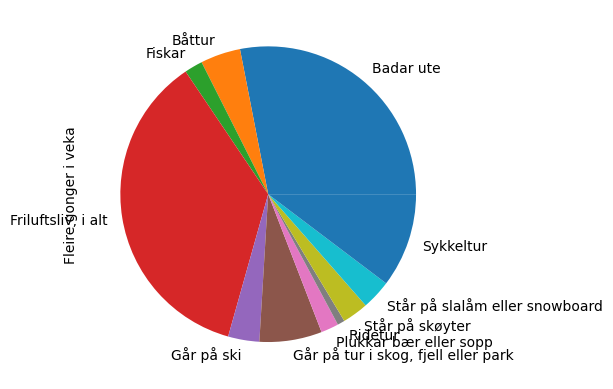

In [41]:
df_pivot.loc[:, "Fleire gonger i veka"].plot.pie()

<Axes: ylabel='Fiskar'>

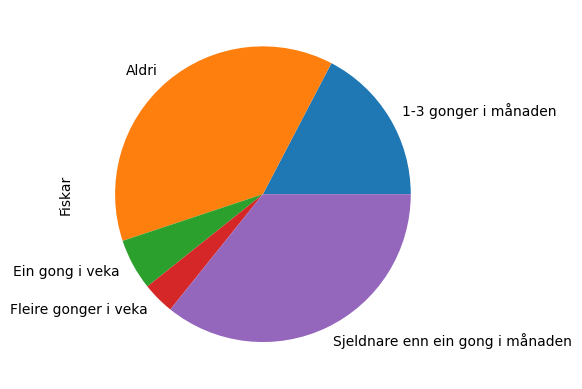

In [42]:
df_pivot.loc["Fiskar"].plot.pie()